In [78]:
import pandas as pd
from pandas_datareader import data as pdr
import yfinance as yfin
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy as scp
from scipy import stats

In [79]:
Ticker = ['^NSEI']

# Indicate the start and end dates
start = dt.datetime.now().replace(year=dt.datetime.now().year - 1)
end = dt.datetime.now()

nifty = yfin.download(Ticker, start = start, end = end)
print(nifty)

[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2025-05-12  24924.699219  24944.800781  24378.849609  24420.099609  368700
2025-05-13  24578.349609  24973.800781  24547.500000  24864.050781  423000
2025-05-14  24666.900391  24767.550781  24535.550781  24613.800781  345500
2025-05-15  25062.099609  25116.250000  24494.449219  24694.449219  500800
2025-05-16  25019.800781  25070.000000  24953.050781  25064.650391  432700
...                  ...           ...           ...           ...     ...
2026-05-06  24330.949219  24356.500000  23997.900391  24171.000000  429200
2026-05-07  24326.650391  24482.099609  24284.000000  24398.500000  440600
2026-05-08  24176.150391  24253.800781  24126.650391  24233.650391  335900
2026-05-11  23815.849609  23997.449219  23799.099609  23970.099609  390100
2026-05-12  23379.550781 

In [80]:
nifty.head()

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2025-05-12,24924.699219,24944.800781,24378.849609,24420.099609,368700
2025-05-13,24578.349609,24973.800781,24547.500000,24864.050781,423000
2025-05-14,24666.900391,24767.550781,24535.550781,24613.800781,345500
2025-05-15,25062.099609,25116.250000,24494.449219,24694.449219,500800
2025-05-16,25019.800781,25070.000000,24953.050781,25064.650391,432700


In [81]:
nifty['Close'].pct_change(1) * 100

Ticker,^NSEI
Date,
2025-05-12,NaN
2025-05-13,-1.389584
2025-05-14,0.360280
2025-05-15,1.602144
2025-05-16,-0.168776
...,...
2026-05-06,1.240590
2026-05-07,-0.017668
2026-05-08,-0.618663


In [82]:
nifty['Daily returns'] = nifty['Close'].pct_change(1) * 100
nifty['Daily returns']

Date
2025-05-12         NaN
2025-05-13   -1.389584
2025-05-14    0.360280
2025-05-15    1.602144
2025-05-16   -0.168776
                ...   
2026-05-06    1.240590
2026-05-07   -0.017668
2026-05-08   -0.618663
2026-05-11   -1.490315
2026-05-12   -1.831968
Name: Daily returns, Length: 248, dtype: float64

In [83]:
nifty['Daily_Returns'] = nifty['Daily returns'].fillna(0)
nifty.Daily_Returns

Date
2025-05-12    0.000000
2025-05-13   -1.389584
2025-05-14    0.360280
2025-05-15    1.602144
2025-05-16   -0.168776
                ...   
2026-05-06    1.240590
2026-05-07   -0.017668
2026-05-08   -0.618663
2026-05-11   -1.490315
2026-05-12   -1.831968
Name: Daily_Returns, Length: 248, dtype: float64

In [84]:
nifty.Daily_Returns.mean()

-0.022492778007650118

In [85]:
nifty.Daily_Returns.std()

0.8149577623715903

In [86]:
#log_returns = ln(p(t) / p(t -1)) = ln(p(t)) - ln(p(t - 1))

In [87]:
nifty['log_returns'] = np.log(nifty['Close'] / nifty['Close'].shift(1))

In [88]:
nifty['log_returns'] = nifty['log_returns'].fillna(0)
nifty['log_returns']

Date
2025-05-12    0.000000
2025-05-13   -0.013993
2025-05-14    0.003596
2025-05-15    0.015894
2025-05-16   -0.001689
                ...   
2026-05-06    0.012330
2026-05-07   -0.000177
2026-05-08   -0.006206
2026-05-11   -0.015015
2026-05-12   -0.018490
Name: log_returns, Length: 248, dtype: float64

In [89]:
nifty['log_return'] = np.log(nifty['Close']).diff()

In [90]:
nifty['log_return']

Date
2025-05-12         NaN
2025-05-13   -0.013993
2025-05-14    0.003596
2025-05-15    0.015894
2025-05-16   -0.001689
                ...   
2026-05-06    0.012330
2026-05-07   -0.000177
2026-05-08   -0.006206
2026-05-11   -0.015015
2026-05-12   -0.018490
Name: log_return, Length: 248, dtype: float64

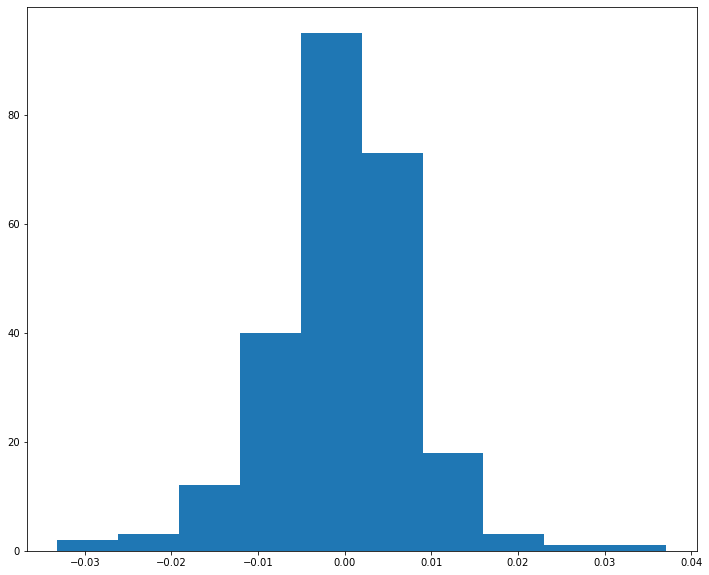

In [91]:
log_return = nifty['log_returns']

plt.figure(figsize = (12, 10))
plt.hist(log_return)

plt.show()

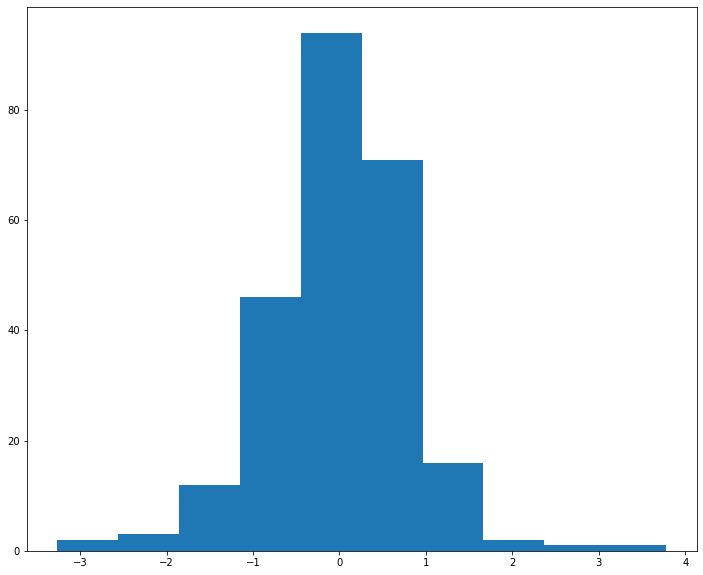

In [92]:
returns = nifty['Daily_Returns'].to_frame()

plt.figure(figsize = (12, 10))
plt.hist(returns)

plt.show()

In [93]:
stats.describe(nifty['Daily_Returns'])

DescribeResult(nobs=248, minmax=(-3.2620779262169552, 3.7783792956159967), mean=-0.022492778007650132, variance=0.6641561544497092, skewness=-0.03576838572804506, kurtosis=2.6587059085798144)

In [94]:
stats.describe(nifty['log_returns'])

DescribeResult(nobs=248, minmax=(-0.03316469831760482, 0.03708747109816642), mean=-0.00025805446075779007, variance=6.648645366601085e-05, skewness=-0.09217172658853114, kurtosis=2.6047745808480993)

In [95]:
#build a cdf for returns, from scratch
returns

,Daily_Returns
Date,
2025-05-12,0.000000
2025-05-13,-1.389584
2025-05-14,0.360280
2025-05-15,1.602144
2025-05-16,-0.168776
...,...
2026-05-06,1.240590
2026-05-07,-0.017668
2026-05-08,-0.618663


In [96]:
returns_cdf = returns.sort_values(by = 'Daily_Returns', ascending = True, inplace = False)
returns_cdf['rowNumber'] = range(1, len(returns_cdf) + 1)
returns_cdf['cdf'] = returns_cdf.rowNumber / len(returns_cdf)

In [97]:
returns_cdf

,Daily_Returns,rowNumber,cdf
Date,,,
2026-03-19,-3.262078,1,0.004032
2026-03-23,-2.603775,2,0.008065
2026-03-30,-2.139386,3,0.012097
2026-03-27,-2.088905,4,0.016129
2026-03-13,-2.064587,5,0.020161
...,...,...,...
2026-04-15,1.630064,244,0.983871
2026-03-25,1.719806,245,0.987903
2026-03-24,1.775668,246,0.991935


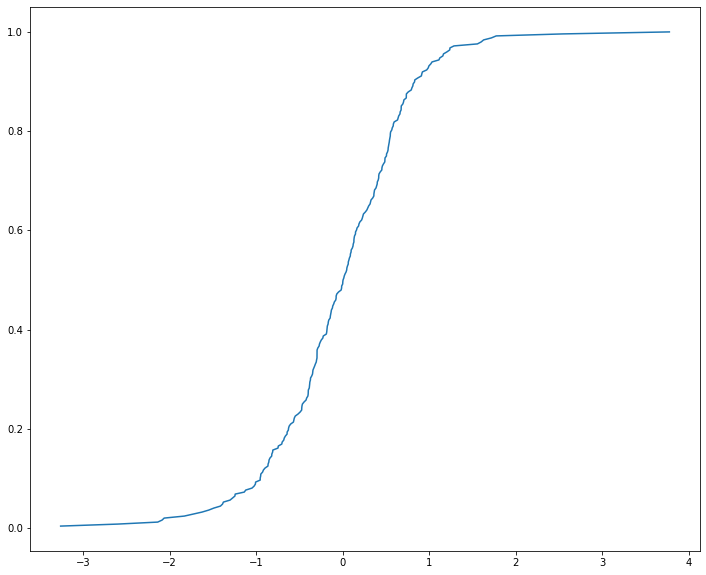

In [98]:
plt.figure(figsize = (12, 10))
plt.plot(returns_cdf.Daily_Returns, returns_cdf.cdf)

plt.show()

In [99]:
returns

,Daily_Returns
Date,
2025-05-12,0.000000
2025-05-13,-1.389584
2025-05-14,0.360280
2025-05-15,1.602144
2025-05-16,-0.168776
...,...
2026-05-06,1.240590
2026-05-07,-0.017668
2026-05-08,-0.618663


In [100]:
returns_sorted = returns.sort_values('Daily_Returns')
returns_sorted['cdf'] = stats.norm.cdf(returns_sorted.Daily_Returns)

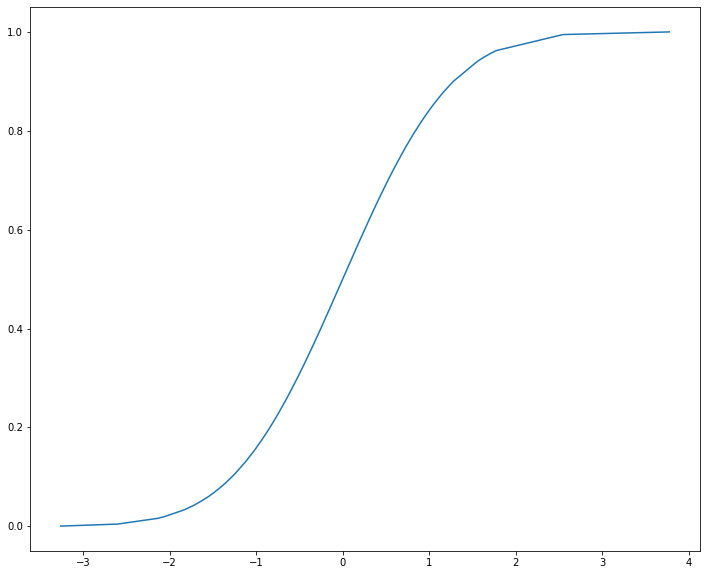

In [101]:
plt.figure(figsize = (12, 10))
plt.plot(returns_sorted.Daily_Returns, returns_sorted.cdf)

plt.show()

In [102]:
returns = nifty.Daily_Returns

In [104]:
stats.norm.fit(returns)

(-0.022492778007650132, 0.8133130427085449)